Task 10. Camera Calibration and Lens Undistortion   

Print or display a standard checkerboard calibration pattern (9x6 internal corners is common; plenty of printable versions online). Using the same phone or webcam camera each time, capture 12 to 15 photos of the checkerboard from different angles, distances, and tilts, making sure it fills different parts of the frame across the set. 

Run cv2.findChessboardCorners() on each image to locate the internal corners, refine them with cv2.cornerSubPix(), and feed the results into cv2.calibrateCamera() to compute the camera matrix and distortion coefficients. Report your computed focal lengths (fx, fy), principal point (cx, cy), and the overall reprojection error. 

Take one more photo with the same camera of an ordinary scene that has long straight lines near the frame edges (a doorway, a bookshelf, a window frame works well). Undistort it with cv2.undistort() using your computed parameters and compare the before and after. The lines that were curved near the edges should now look straight. 

This one is genuinely fiddly: corner detection will fail on some of your images (usually due to glare, blur, or the board being too small in frame), so expect to reshoot a few. Note in your write-up how many images you had to discard and why. 

In [3]:
import cv2
import numpy as np
import glob


In [22]:

CHECKERBOARD = (9, 6)
criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

In [23]:
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)

objp[:, :2] = np.mgrid[
    0:CHECKERBOARD[0],
    0:CHECKERBOARD[1]
].T.reshape(-1, 2)

objpoints = []
imgpoints = []


In [35]:

images = glob.glob("Checkerboard/*.jpeg")

successful = 0
discarded = 0
count=0
for fname in images:
    count+=1
    

    img = cv2.imread(fname)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # Detect checkerboard corners
    ret, corners = cv2.findChessboardCorners(
        gray,
        CHECKERBOARD,
        None
    )

    if ret:
        print(count)

        successful += 1

        objpoints.append(objp)

        # Refine corner locations
        corners2 = cv2.cornerSubPix(
            gray,
            corners,
            (11,11),
            (-1,-1),
            criteria
        )

        imgpoints.append(corners2)

        # Draw corners
        cv2.drawChessboardCorners(
            img,
            CHECKERBOARD,
            corners2,
            ret
        )

        cv2.imshow("Corners", img)
        cv2.waitKey(1000)

    else:

        discarded += 1

cv2.destroyAllWindows()
print(successful)


1
2
3
5
6
7
14
16
8


In [37]:

ret, cameraMatrix, distCoeffs, rvecs, tvecs = cv2.calibrateCamera(

    objpoints,
    imgpoints,
    gray.shape[::-1],
    None,
    None

)


print("Camera Matrix")

print(cameraMatrix)

print("\nDistortion Coefficients")
print(distCoeffs)

fx = cameraMatrix[0,0]
fy = cameraMatrix[1,1]
cx = cameraMatrix[0,2]
cy = cameraMatrix[1,2]
print("\nFocal length")
print("fx =", fx)
print("fy =", fy)
print("\nPrinciple point")
print("cx =", cx)
print("cy =", cy)


Camera Matrix
[[987.20638597   0.         639.65286913]
 [  0.         988.71479018 479.23457325]
 [  0.           0.           1.        ]]

Distortion Coefficients
[[ 1.48010837e-01 -9.45826869e-01 -2.00952151e-04  8.18275100e-06
   1.50549287e+00]]

Focal length
fx = 987.2063859724364
fy = 988.7147901845279

Principle point
cx = 639.6528691345015
cy = 479.2345732506929


In [32]:

mean_error = 0

for i in range(len(objpoints)):

    imgpoints2, _ = cv2.projectPoints(

        objpoints[i],
        rvecs[i],
        tvecs[i],
        cameraMatrix,
        distCoeffs

    )

    error = cv2.norm(
        imgpoints[i],
        imgpoints2,
        cv2.NORM_L2
    ) / len(imgpoints2)

    mean_error += error

mean_error /= len(objpoints)

print("\nReprojection Error =", mean_error)

print("\nSuccessful Images =", successful)
print("Discarded Images =", discarded)


Reprojection Error = 0.06645328542935912

Successful Images = 8
Discarded Images = 8


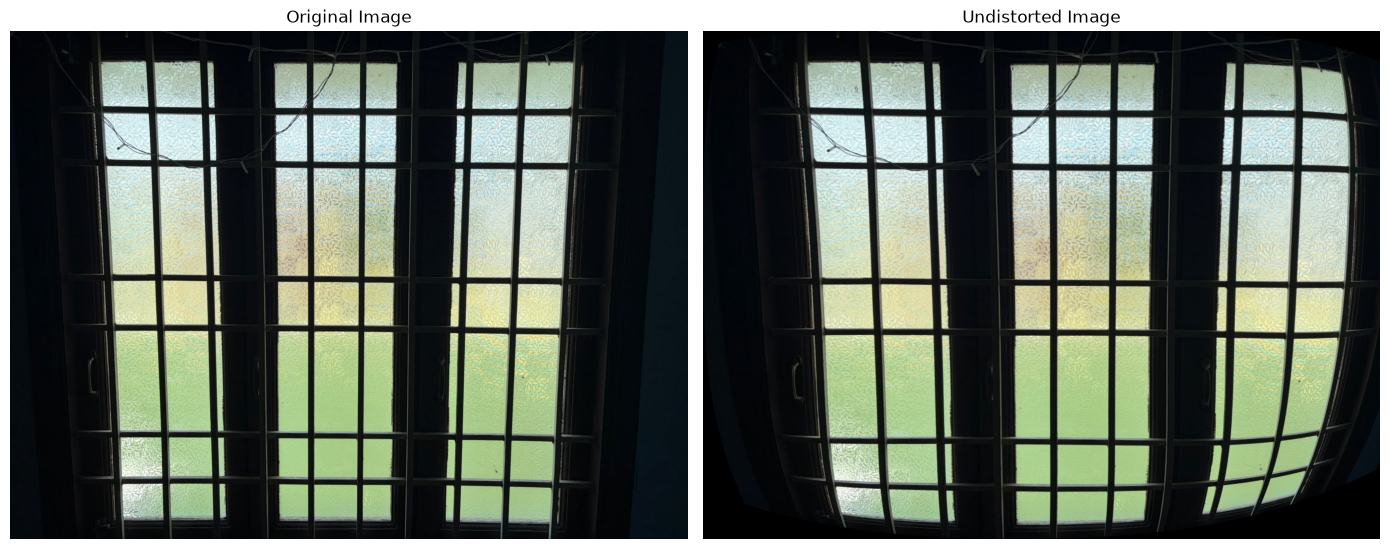

In [38]:
import matplotlib.pyplot as plt


img = cv2.imread("raw_captures/Test.jpeg")

h, w = img.shape[:2]

# Compute optimal camera matrix
newCameraMatrix, roi = cv2.getOptimalNewCameraMatrix(
    cameraMatrix,
    distCoeffs,
    (w, h),
    1,
    (w, h)
)

# Undistort image
undistorted = cv2.undistort(
    img,
    cameraMatrix,
    distCoeffs,
    None,
    newCameraMatrix
)

# Save result
cv2.imwrite("undistorted_result.jpg", undistorted)

# Convert BGR to RGB for Matplotlib
original_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(undistorted_rgb)
plt.title("Undistorted Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Initially, I captured 11 checkerboard images from different angles for camera calibration. However, only 2 images were successfully detected, while the remaining images were discarded because cv2.findChessboardCorners() could not detect all the internal corners.

After examining the failed images, I identified the following issues:

Some images contained glare from the laptop screen, which reduced the visibility of the checkerboard corners.
A few images were slightly blurred due to camera movement during capture.
Some images were captured at very steep tilt angles, making it difficult for OpenCV to detect the checkerboard accurately.

To resolve these issues, I recaptured the calibration images while ensuring that the checkerboard was in focus, minimizing screen glare, and using moderate viewing angles. After replacing the poor-quality images with clearer ones, the corner detection was successful, allowing the camera calibration to complete correctly.